# Task4

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# seaborn graphics settings
sns.set(color_codes=True)

df = pd.read_csv('supermarkets_data_enriched.csv')[['id',
                                                    'brand',
                                                    'lat',
                                                    'lon',
                                                    'pop',
                                                    'pop_dens',
                                                    'frg_pct',
                                                    'emp']]

print(df.head())

           id   brand        lat       lon   pop    pop_dens    frg_pct  \
0    33126515    Spar  47.155616  9.037915  3876   97.142857  13.054696   
1   280130028    ALDI  47.155492  9.039666  3876   97.142857  13.054696   
2  6122906632  Denner  47.158959  9.044477  3876   97.142857  13.054696   
3  9019298862    Lidl  47.155185  9.038472  3876   97.142857  13.054696   
4    36726161  Migros  47.226191  8.980329  6489  860.610080  27.862537   

      emp  
0  1408.0  
1  1408.0  
2  1408.0  
3  1408.0  
4  3500.0  


### Count the number of supermarkets per brand (e.g. Migros, Coop, etc.).

In [63]:
df_brand =  df['brand'].value_counts()
print(df_brand)

brand
Coop                                     497
Migros                                   495
Denner                                   423
Volg                                     210
ALDI                                      72
Spar                                      63
Lidl                                      58
Aldi                                      52
VOI Migros Partner                        44
Landi                                     39
Alnatura                                  15
Migros-Outlet                             12
VOI                                        8
Pam                                        4
Jumbo                                      2
Crai                                       2
Globus                                     2
ZWIBOL                                     1
Lidl Schweiz                               1
Eurospar                                   1
Proxi                                      1
Denner;Migros                              1
gazi

### a barchart with the number of supermarkets per brand

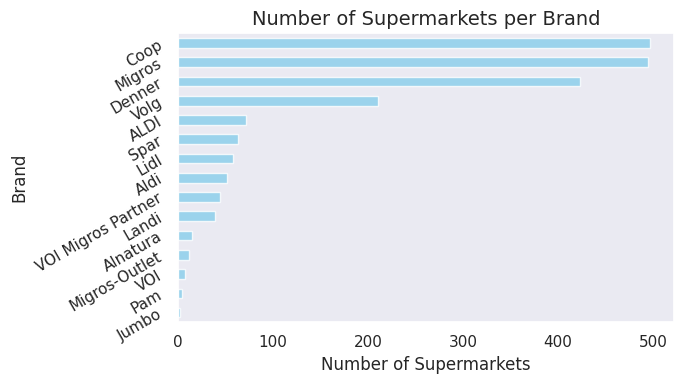

In [64]:
# Group data by rooms (only the topmost 15 values are shown)
df_brand = df['brand'].value_counts().nlargest(15).sort_values(ascending=True)

# Plotting the bar chart
plt.figure(figsize=(7,4))
df_brand.plot(kind='barh', color='skyblue', alpha=0.8)

# Adding labels and title
plt.ylabel('Brand', fontsize=12)
plt.xlabel('Number of Supermarkets', fontsize=12)
plt.title('Number of Supermarkets per Brand', fontsize=14)
plt.yticks(rotation=30)

plt.grid()
# Show the chart
plt.tight_layout()
plt.show()

### the .PairGrid() method from the seaborn library to create a scatterplotmatrix of the numeric variables lat, lon, pop, pop_dens, frg_pct, emp.

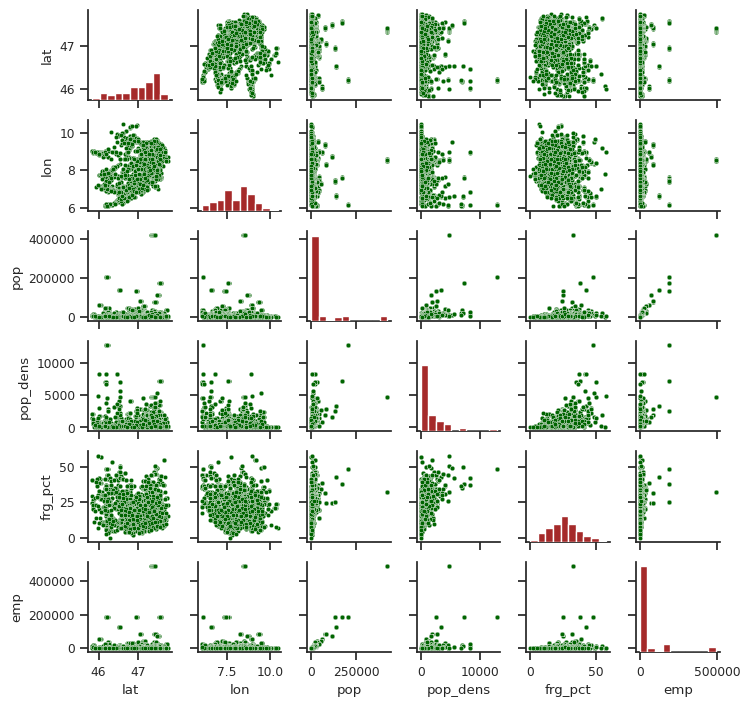

In [65]:
sns.set(style="ticks", font_scale=0.8)
g = sns.PairGrid(df[['lat', 
                     'lon', 
                     'pop', 
                     'pop_dens',
                     'frg_pct',
                     'emp']], 
                 height=1.2, 
                 aspect=1)
g.map_upper(sns.scatterplot,color='darkgreen', s=10)
g.map_lower(sns.scatterplot, color='darkgreen', s=10)
g.map_diag(plt.hist, color='brown')

### plot with the locations of supermarkets in different colors according to their brand. The plot must contain at least locations of the brands: Denner, Volg & Landi

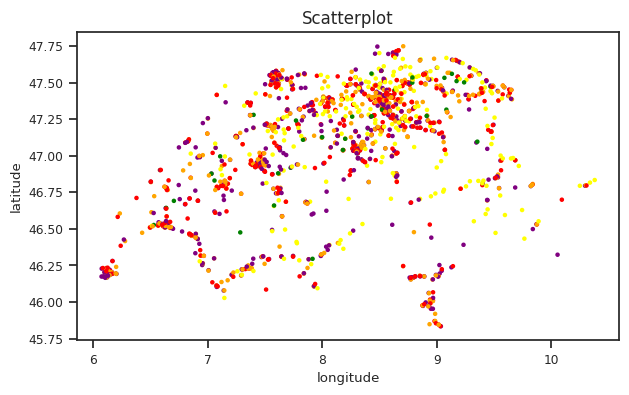

In [66]:
df_sub = df.loc[df['brand'].isin(['Denner', 'Volg', 'Landi', 'Migros', 'Coop'])]

plt.figure(figsize=(7,4))
plt.scatter(df_sub['lon'], 
           df_sub['lat'], 
           color=df_sub['brand'].map({'Denner': 'red', 
                  'Volg': 'yellow', 
                  'Landi': 'green', 
                  'Migros': 'orange', 
                  'Coop': 'purple'}), 
           alpha=1.0,
           s=5)
plt.title('Scatterplot', fontsize=12)
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()